In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pre_processing import pre_process, json_decode


sns.set_palette("hsv_r")

# This affects things like the size of the labels, lines, and other elements of the plot, but not the overall style. 
# The base context is “notebook”, and the other contexts are “paper”, “talk”, and “poster”, which are version of 
# the notebook parameters scaled by .8, 1.3, and 1.6, respectively.
sns.set_context("talk")

%config Inline.figure_format = 'retina'
%matplotlib inline

# new 

## Read in Data 

In [22]:
# File paths for each experimental condition (can contain multiple subjects/files) 
file_paths_baseline = [
    "../data/csv_files/01_baseline_withoutFB.csv",
    "../data/csv_files/02_baseline_withoutFB.csv",
    "../data/csv_files/03_baseline_withoutFB.csv",
    "../data/csv_files/04_baseline_withoutFB.csv"
]

file_paths_repulse = [
    "../data/csv_files/01_repulse_withoutFB.csv",
    "../data/csv_files/02_repulse_withoutFB.csv",
    "../data/csv_files/03_repulse_withoutFB.csv",
    "../data/csv_files/04_repulse_withoutFB.csv"
]

file_paths_udl = [
    "../data/csv_files/01_udl_withoutFB.csv",
    "../data/csv_files/02_udl_withoutFB.csv",
    "../data/csv_files/03_udl_withoutFB.csv",
    "../data/csv_files/04_udl_withoutFB.csv"
]
# Subject identifiers corresponding to the datasets
subject_list = ["abby", "yannie", "eric", "paul"]


# Load CSV files & label condition
df_baseline_raw = pre_process(file_paths_baseline, subject_list)
df_baseline_raw['phase'] = 'baseline'

df_repulse_raw = pre_process(file_paths_repulse, subject_list)
df_repulse_raw['phase'] = 'repulse'

df_udl_raw = pre_process(file_paths_udl, subject_list)
df_udl_raw['phase'] = 'udl'

# Combine all conditions into a single dataset
df = pd.concat([df_baseline_raw, df_repulse_raw, df_udl_raw]).reset_index(drop=True)

# Reset the trial number column that resets for each subject
df["TN"] = df.groupby("SN").cumcount()

# CHECK 
# print(df['phase'].value_counts())
# print(df.head())


## Define Functions 

In [23]:
# function to unpack repeated target value from series
# WE HAVENT USE THIS ONE YET.. copied from Jeremy's analysis script
def find_rep(group):
    vals = group['Repeated_Target'].iloc[0]
    return vals[1:4]   

#function returns df where N-1 is a single target, 
#to compare the repulsive and attractive effect of a single target
def N_finder(group, N_minus_targ):
    N_trial_num = group.loc[(group['target_angle'] == N_minus_targ),'TN'] + 1
    N_df = group.loc[(group['TN'].isin(N_trial_num))]
    return N_df

def add_bias_correction(df, angle_col, phase_name, epoch):
    """
    calcylate target-specific bias and corrected angle for a given phase and angle column
    """
    bias_col = f"bias_{phase_name}_{angle_col}"
    corrected_col = f"corrected_{phase_name}_{angle_col}"

    bias = (
        df.loc[
            (df["TN"] >= epoch[0]) &
            (df["TN"] <= epoch[1]) &
            (~df["mt"].isna()) &
            (df["rt"] > 0.5) &
            (df[angle_col].abs() < 60)
        ]
        .groupby(["SN", "target_angle"], as_index=False)[angle_col]
        .mean()
        .rename(columns={angle_col: bias_col})
    )

    # merge bias back into dataframe
    df = df.merge(bias, on=["SN", "target_angle"], how="left")

    # wrap the angle
    diff = np.deg2rad(df[angle_col] - df[bias_col])

    df[corrected_col] = np.rad2deg(
        np.arctan2(np.sin(diff), np.cos(diff))
    )
    return df

## Data Wrangling 

In [24]:
## Define epochs for each phase of the experiment (trial number ranges for each phase)
epochs = {
    'baseline':(0, 15),      # Baseline reaching
    'repulse':(16, 715),   # Main experiment block
    'repulse_clean':(116, 715),   # For bias correctino 
    'udl':(716, 1579),   # Main experiment block
}

# # Calculate bias for each participant, which is used for bias correction in the UDL condition
# bias_subset = (
#     df.loc[(df['TN'] >= epochs['repulse_clean'][0]) & (df['TN'] <= epochs['repulse_clean'][1]) & 
#     # df.loc[(df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1]) & 
#     (~df['mt'].isna()) & (df['rt'] > .500) & (df['theta_pv'].abs() < 60)]
#     .groupby(['SN', 'target_angle'], as_index=False)['theta_pv']
#     .mean()
#     .rename(columns={'theta_pv': 'bias'})
# )
# df = df.merge(bias_subset, on=['SN', 'target_angle'], how='left')

# # Correct for target-level reach biases by subtraction of mean hand angle to a target
# RadCorrDiff = np.deg2rad(df['theta_pv'] - df['bias'])
# df['angle_error_corrected'] = np.rad2deg(np.arctan2(np.sin(RadCorrDiff), np.cos(RadCorrDiff)))

## running add_bias_correction for all angle calculations & 
angle_cols = ["theta_40", "theta_100", "theta_pv", "theta_end"]
phase_info = {
    "repulse": epochs["repulse_clean"]}

for phase_name, epoch in phase_info.items():
    for angle in angle_cols:
        df = add_bias_correction(
            df,
            angle_col=angle,
            phase_name=phase_name,
            epoch=epoch
        )

## Shift the target angles for participants who had a central target of 60 degrees, so that central target is always at 150 degrees 
# Participants who had central target as 60 degrees
p_list1 = [1, 3]

# Shift all targets so central target is always 150 degrees
mask = df['SN'].isin(set(p_list1))
TA_rad_shift = np.deg2rad(df.loc[mask]['target_angle']) + np.deg2rad(90)
df.loc[mask,'target_angle'] = (np.rad2deg(np.arctan2(np.sin(TA_rad_shift), np.cos(TA_rad_shift))) % 360).round()

# Get target location difference values
df['target_angle_diff'] = pd.Series(pd.NA, index=df.index, dtype='Float64')
# NOTES:
# 1) multiply by -1 because we want positive to be clockwise
# 2) add one to starting index because we want the first trial for every block to be NA
mask = (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1])
RadTAN1diff_repulse = np.deg2rad(df.loc[mask].groupby('SN')['target_angle'].diff(periods=1))*-1
df.loc[mask,'target_angle_diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_repulse), np.cos(RadTAN1diff_repulse)))

# Get target location difference values for UDL block
mask = (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1])
RadTAN1diff_udl = np.deg2rad(df.loc[mask].groupby('SN')['target_angle'].diff(periods=1))*-1
df.loc[mask,'target_angle_diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_udl), np.cos(RadTAN1diff_udl)))

# Round 
df['target_angle_diff'] = df['target_angle_diff'].round().astype('Int64')

# Plot bias across all random phase trials

Text(0, 0.5, 'Corrected Bias')

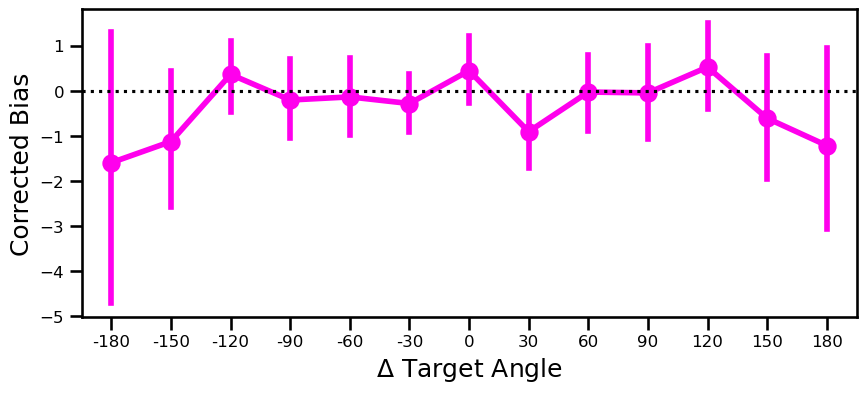

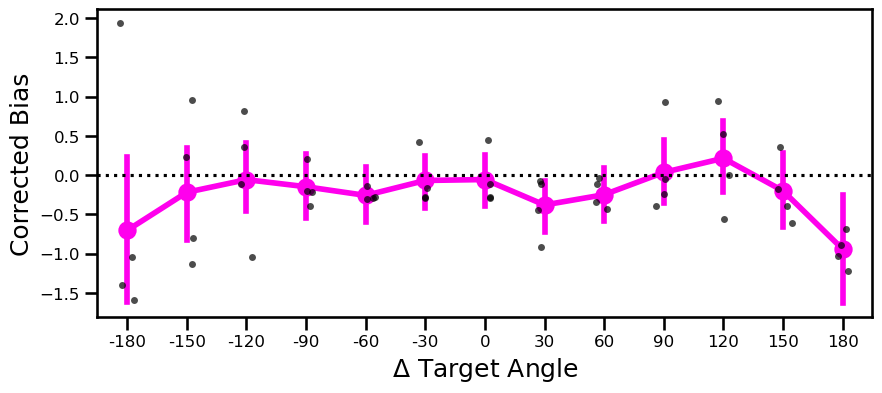

In [25]:
repulse_mask = (
    (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1]) & 
    (~df['mt'].isna()) & # take the median of the RT and MT and mean of the medians 
    (df['rt'] > 0.5) &  
    (np.abs(df['theta_pv']) < 60)
)

df_repulse = df.loc[repulse_mask]

subject_means_repulse = (
    df_repulse
    .groupby(['SN', 'target_angle_diff'])['corrected_repulse_theta_pv']
    .mean()
    .reset_index()
)


fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    # data=df_repulse,
    # to look at a single subject (comment)
    data = df_repulse.loc[df_repulse["SN"] == 2],
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

fig2, ax2 = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax2
)
sns.stripplot(
    data=subject_means_repulse,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax2
)
ax2.axhline(0, color='black', linestyle=':')
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')



# Plot biases in use-dependent phase

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_3812/1143789185.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(N_finder, N_minus_targ=150)
/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_3812/1143789185.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=16, random_state=42))


Text(0, 0.5, 'Corrected Bias')

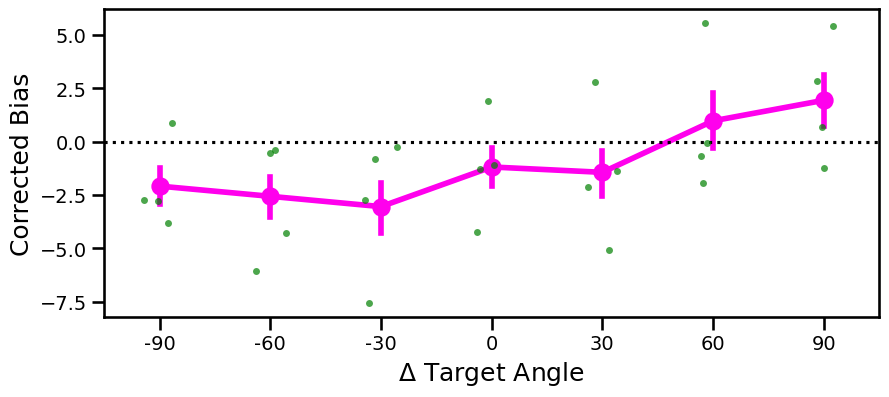

In [26]:
mask_udl = (
    (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1])
    & (~df['mt'].isna()) & (df['rt'] > 0.500) & (df['theta_pv'].abs() < 60))

df_udl = df.loc[mask_udl]

df_udl_constrained = (
    df_udl
    .groupby('SN', as_index=False)
    .apply(N_finder, N_minus_targ=150)
    .reset_index(drop=True)
)
df_udl_constrained = df_udl_constrained.loc[df_udl_constrained['feedback'] == 0]

# should i change so it stores the probe column??
# Split target_angle == 150 and everything else

df_target_150 = df_udl_constrained[df_udl_constrained['target_angle'] == 150]
df_other = df_udl_constrained[df_udl_constrained['target_angle'] != 150]

# Randomly keep 16 of the target_angle == 150 rows

df_target150_keep = (
    df_target_150
    .groupby('SN', group_keys=False)
    .apply(lambda x: x.sample(n=16, random_state=42))
    .reset_index(drop=True)
)

# Combine back together
df_udl_constrained = (
    pd.concat([df_other, df_target150_keep])
    .reset_index(drop=True)
)

subject_means = df_udl_constrained.groupby(['SN', 'target_angle_diff'])['corrected_repulse_theta_pv'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

# sns.stripplot(
#     data=subject_means[subject_means['SN']==1],
#     x='target_angle_diff',
#     y='corrected_repulse_theta_pv',
#     color='red',
#     alpha=0.7,
#     jitter=0.15,
#     size=5,
#     ax=ax
# )

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

Text(0, 0.5, 'theta_pv')

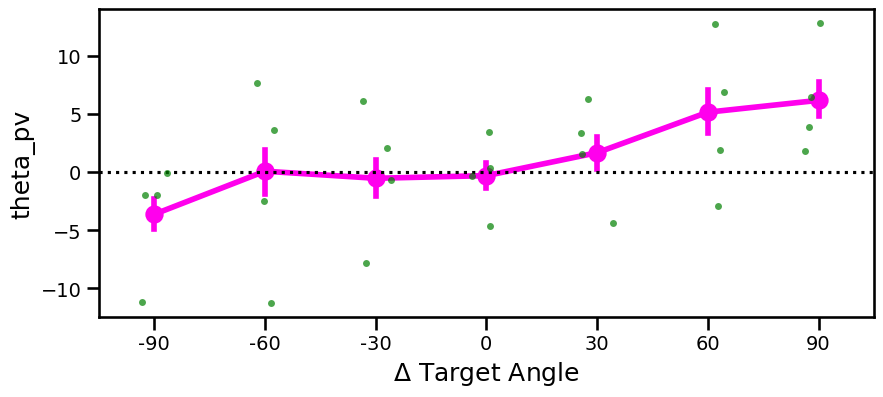

In [27]:
subject_means = df_udl_constrained.groupby(['SN', 'target_angle_diff'])['theta_pv'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle_diff',
    y='theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='theta_pv',
    color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('theta_pv')

## Checking validity of the bias calculation 

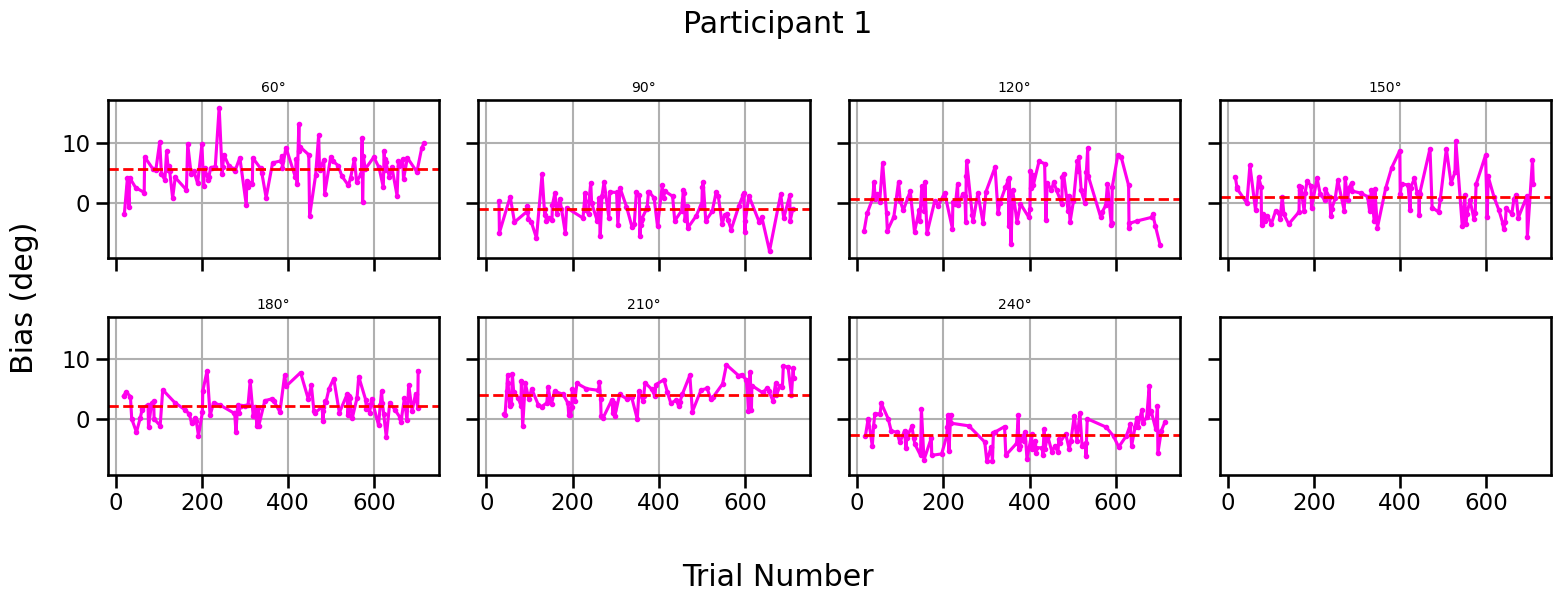

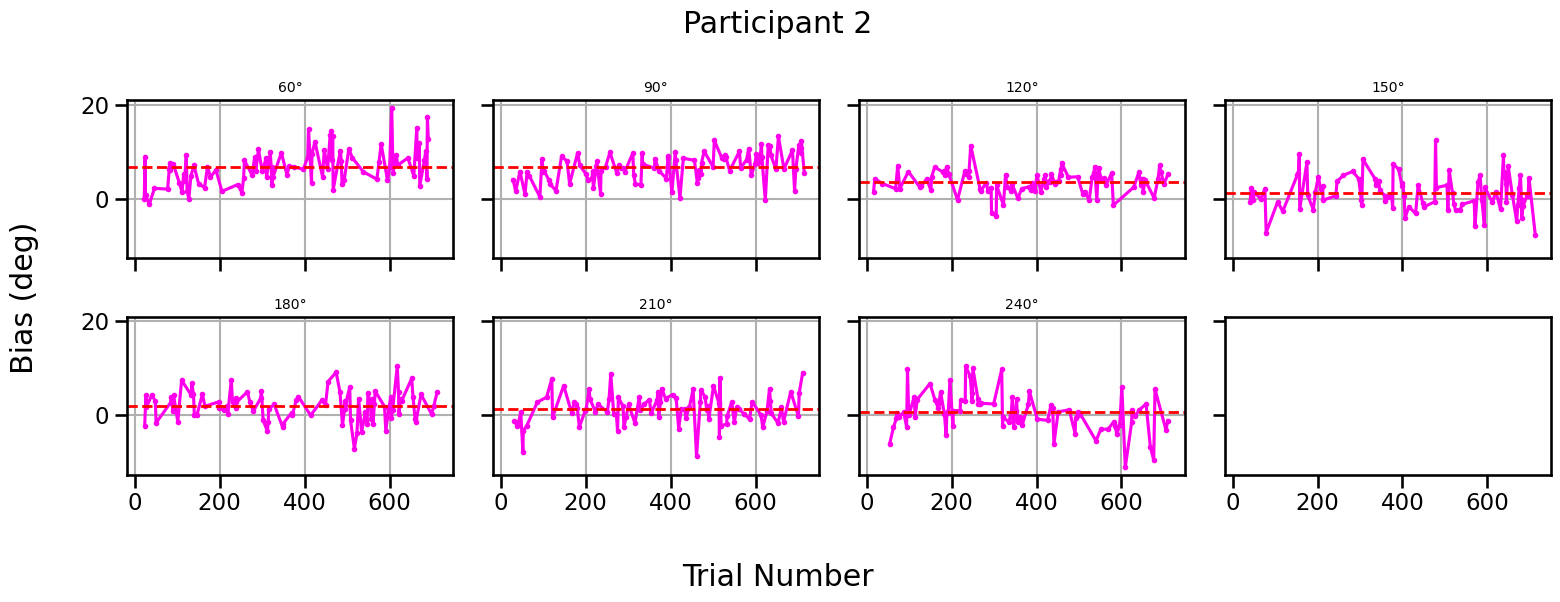

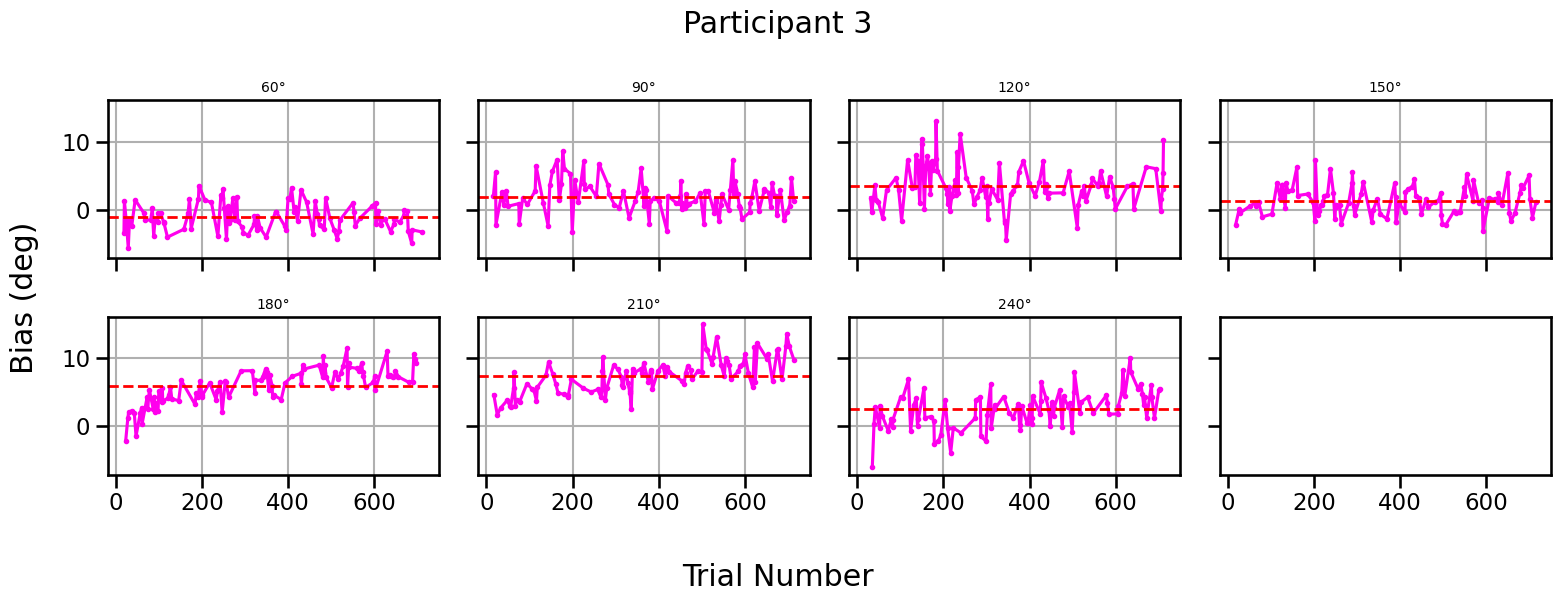

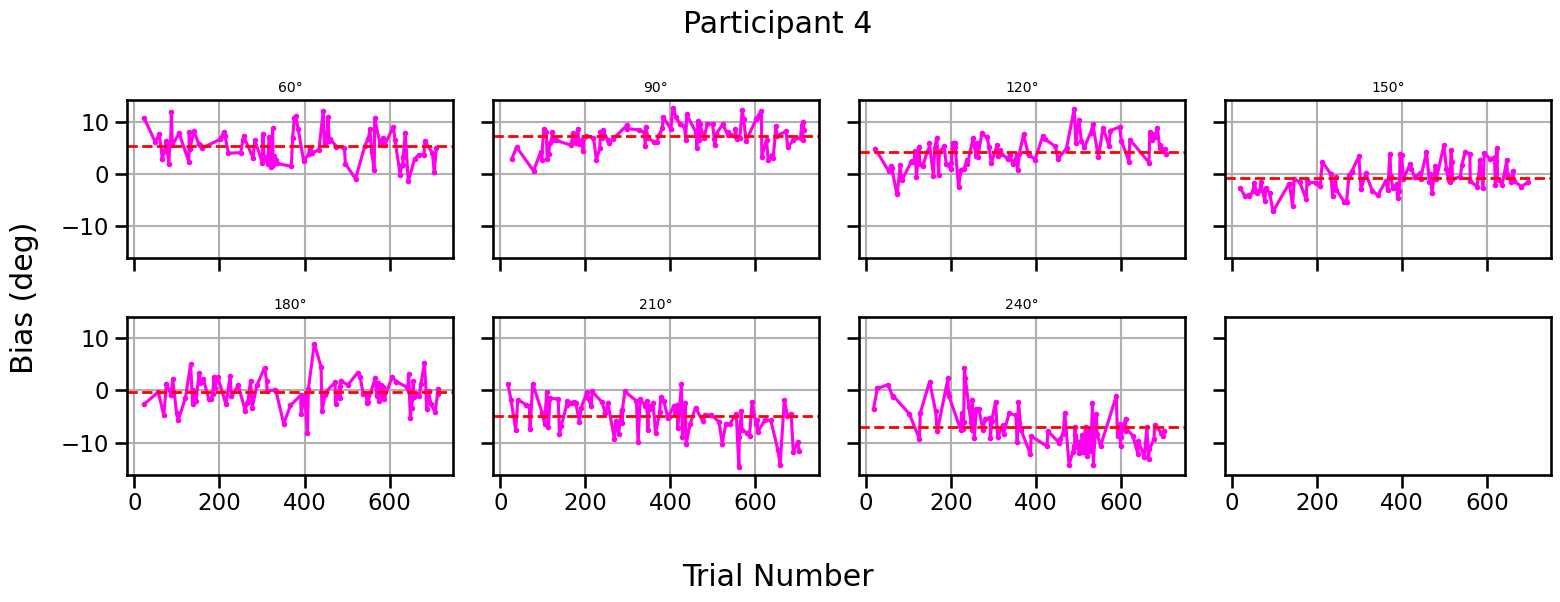

In [28]:
target_angles = sorted(df_repulse['target_angle'].unique())

for sn in df_repulse["SN"].unique():

    ncols = 4
    nrows = int(round(len(target_angles) / ncols,))

    fig, axes = plt.subplots(nrows, ncols,figsize=(4*ncols, 3*nrows),sharex=True,sharey=True)
    axes = np.array(axes).flatten()

    for ax, ta in zip(axes, target_angles):
        df_sn = (df_repulse[(df_repulse["SN"] == sn) &(df_repulse["target_angle"] == ta)].sort_values("TN"))

        ax.plot(df_sn["TN"],df_sn["theta_pv"],'o-',markersize=3)

        mean_val = df_sn["theta_pv"].mean()

        ax.axhline(y=mean_val,color='r',linestyle='--',linewidth=2)

        ax.set_title(f"{ta}°", fontsize=10)
        ax.grid(True)

    fig.suptitle(f"Participant {sn}")
    fig.supxlabel("Trial Number")
    fig.supylabel("Bias (deg)")

    plt.tight_layout()
    plt.show()

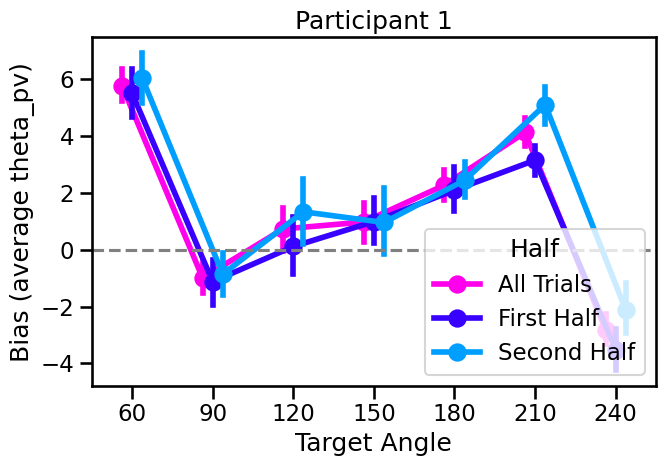

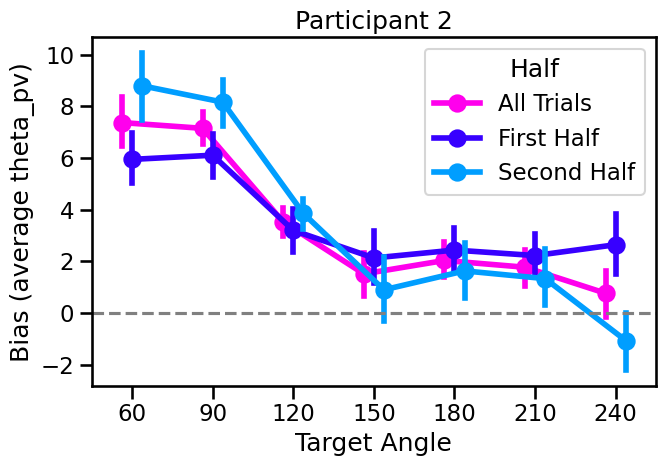

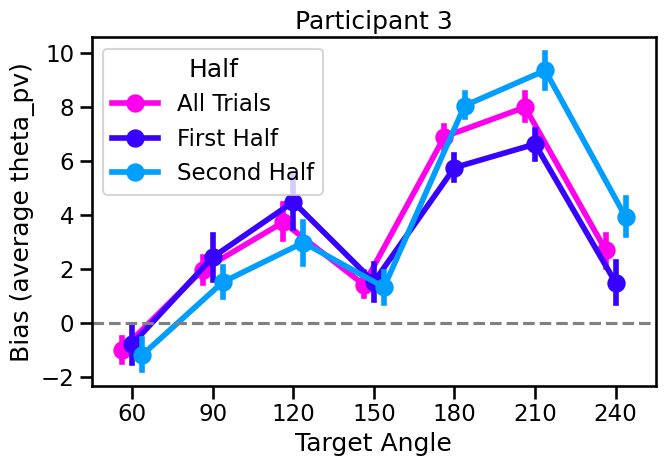

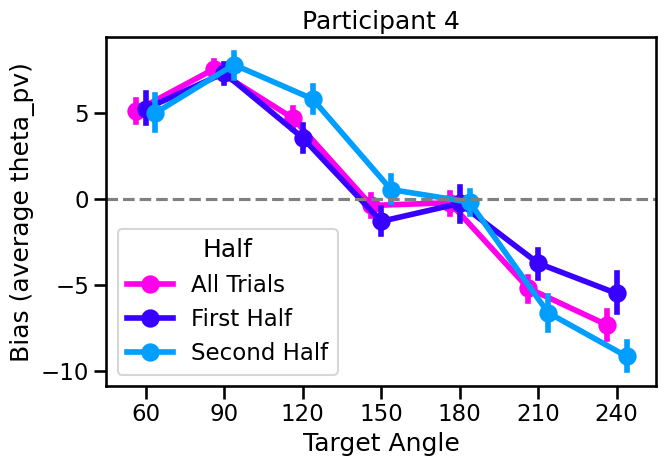

In [29]:
repulse_mask = (
    (df['TN'] >= epochs['repulse_clean'][0]) & (df['TN'] <= epochs['repulse_clean'][1]) & 
    (~df['mt'].isna()) &
    (df['rt'] > 0.5) &  
    (np.abs(df['theta_pv']) < 60)
)
df_repulse = df.loc[repulse_mask]

target_angles = sorted(df_repulse["target_angle"].unique())

for sn in df_repulse["SN"].unique():

    df_sn = df_repulse[df_repulse["SN"] == sn].copy()
    dfs = []

    for angle in target_angles:

        df_angle = df_sn[df_sn["target_angle"] == angle].copy()

        n = len(df_angle)
        half = n // 2

        first = df_angle.iloc[:half].copy()
        second = df_angle.iloc[half:].copy()

        df_angle["Half"] = "All Trials"
        first["Half"] = "First Half"
        second["Half"] = "Second Half"

        dfs.extend([df_angle, first, second])

    plot_df = pd.concat(dfs, ignore_index=True)

    plt.figure(figsize=(7,5))

    sns.pointplot(
        data=plot_df,
        x="target_angle",
        y="theta_pv",
        hue="Half",
        estimator="mean",
        errorbar=("ci", 95),
        dodge=0.25,
        linestyles="-"
    )

    plt.axhline(0, color='gray', linestyle='--')
    plt.xlabel("Target Angle")
    plt.ylabel("Bias (average theta_pv)")
    plt.title(f"Participant {sn}")
    plt.tight_layout()
    plt.show()

# Comparison of theta_40, theta_100, theta_pv, and theta_end 
## REPULSE 

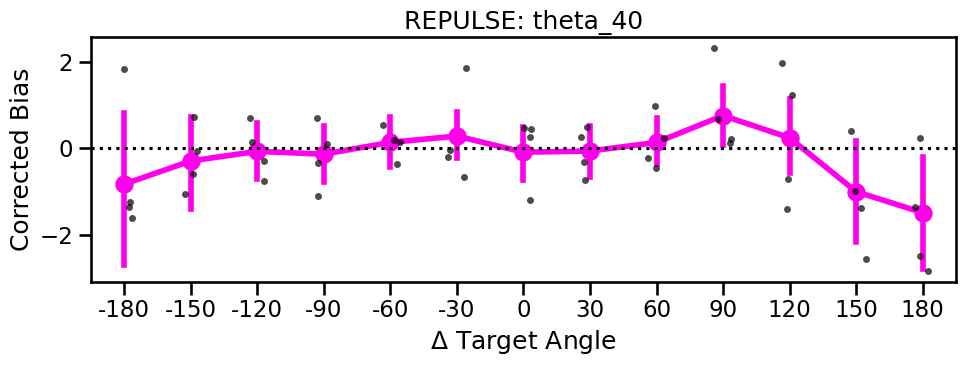

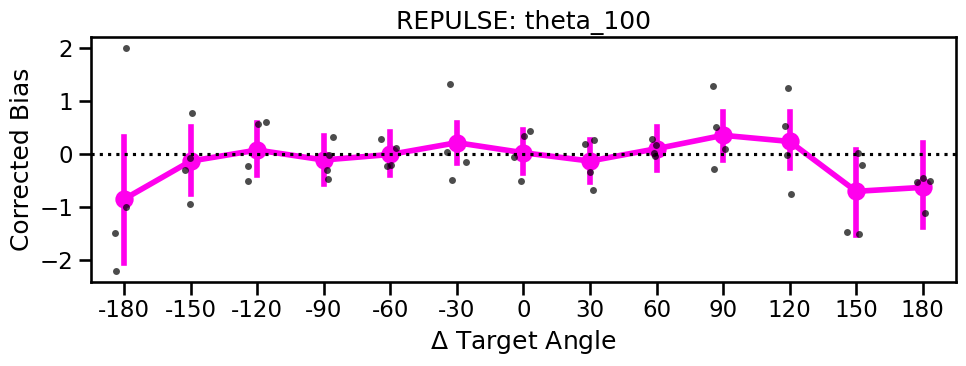

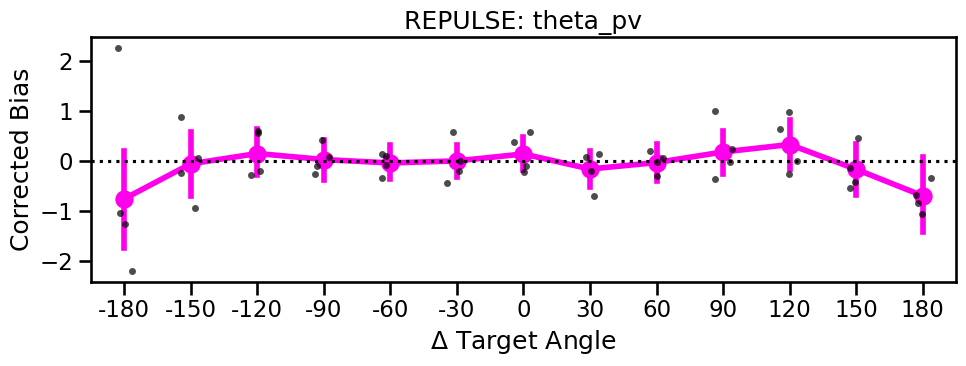

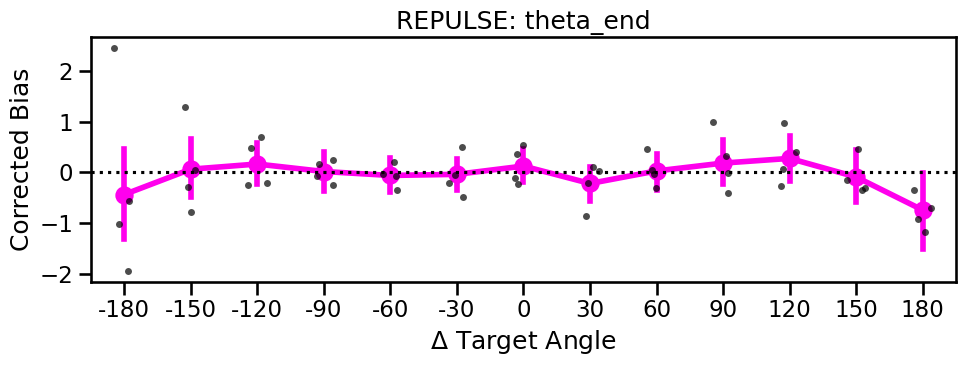

In [30]:
## plotting function
def plot_bias(df_plot, y_col, title):
    '''
    a plotting function that takes in a data frame, the y column (corrected angle), and the title for the graph 
    '''
    subject_means = (
        df_plot
        .groupby(["SN", "target_angle_diff"])[y_col]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10,4))

    sns.pointplot(
        data=df_plot,
        x="target_angle_diff",
        y=y_col,
        estimator="mean",
        errorbar=("ci",95),
        ax=ax
    )

    sns.stripplot(
        data=subject_means,
        x="target_angle_diff",
        y=y_col,
        color="black",
        alpha=0.7,
        jitter=0.15,
        size=5,
        ax=ax
    )

    ax.axhline(0, color="black", linestyle=":")
    ax.set_xlabel(r"$\Delta$ Target Angle")
    ax.set_ylabel("Corrected Bias")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

for angle in angle_cols:
    plot_bias(
        df_repulse,
        y_col=f"corrected_repulse_{angle}",
        title=f"REPULSE: {angle}"
    )

## UDL

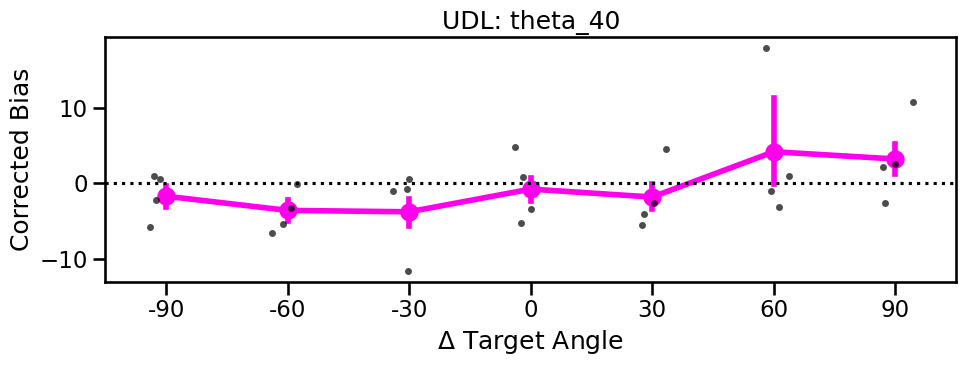

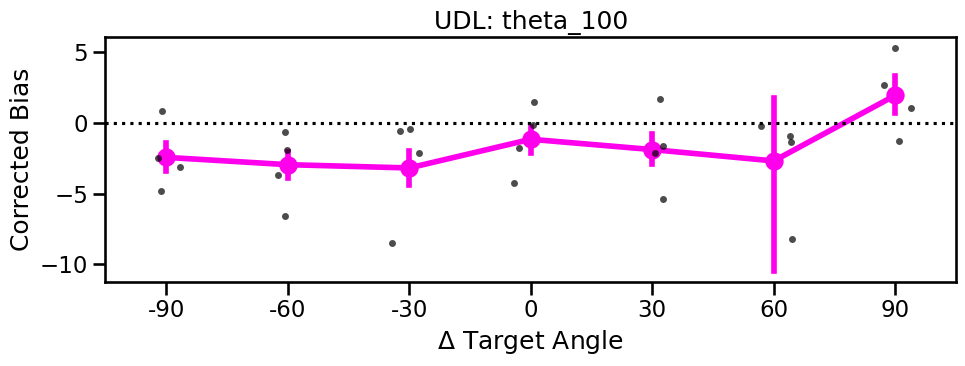

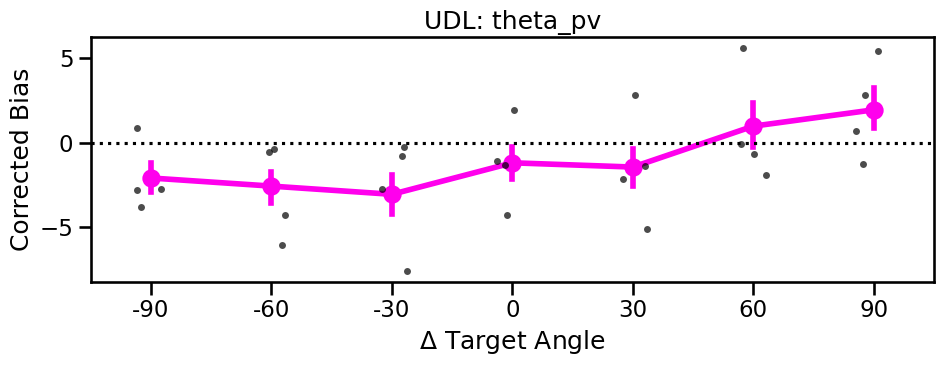

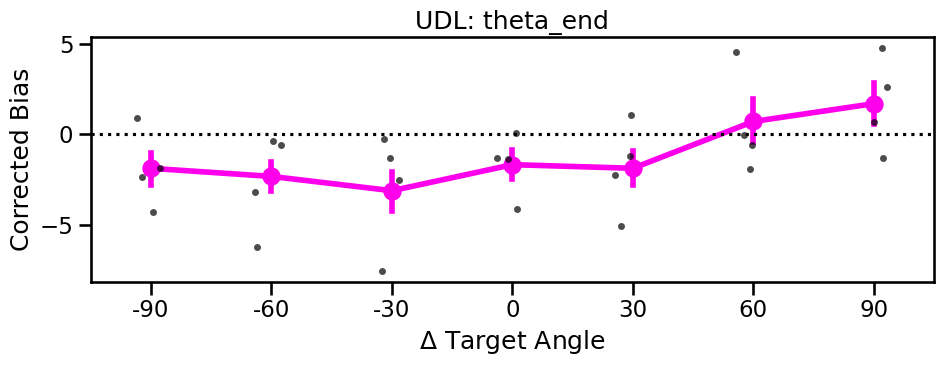

In [31]:
for angle in angle_cols:
    plot_bias(
        df_udl_constrained,
        y_col=f"corrected_repulse_{angle}",
        title=f"UDL: {angle}"
    )
 

 #bias_repulse_theta_100
#corrected_repulse

## Working with different movement times 

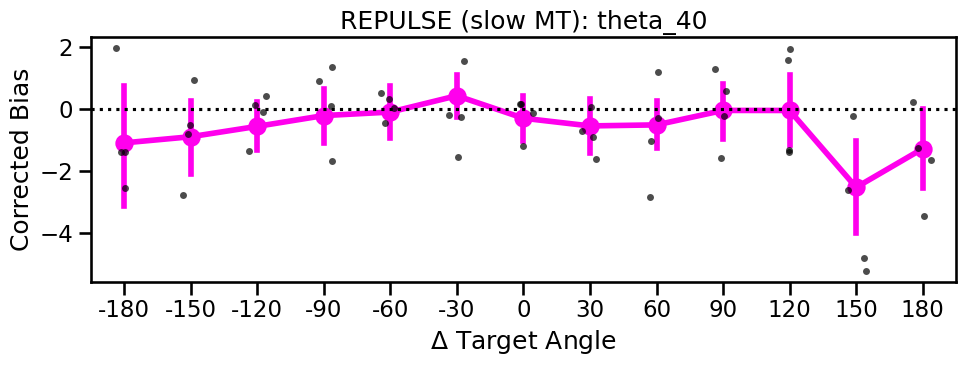

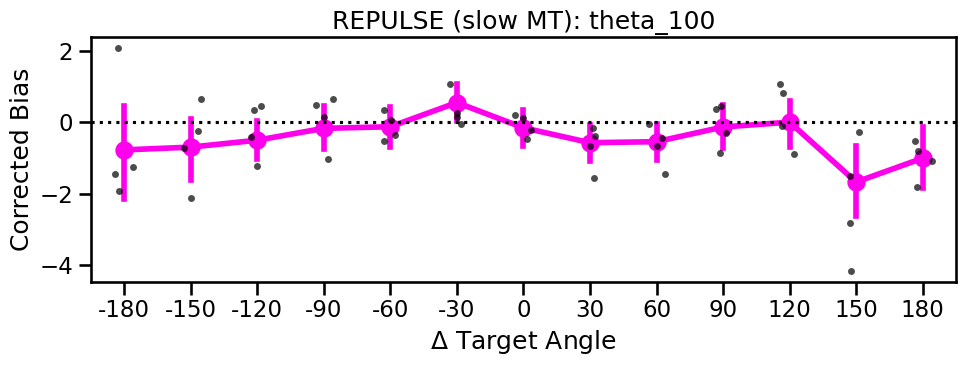

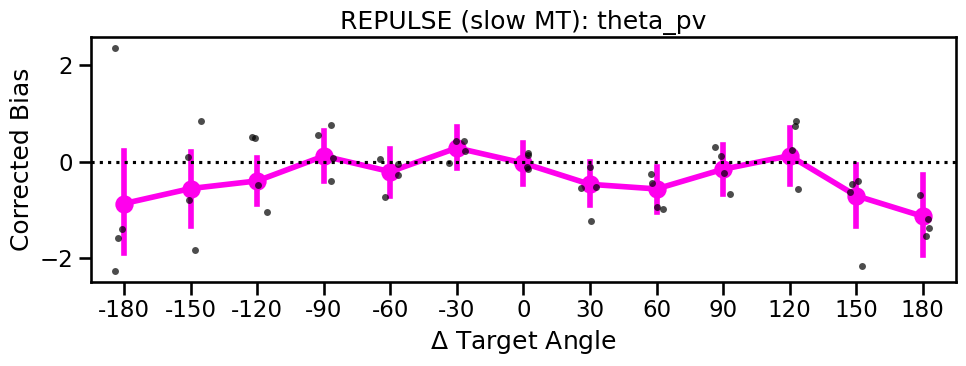

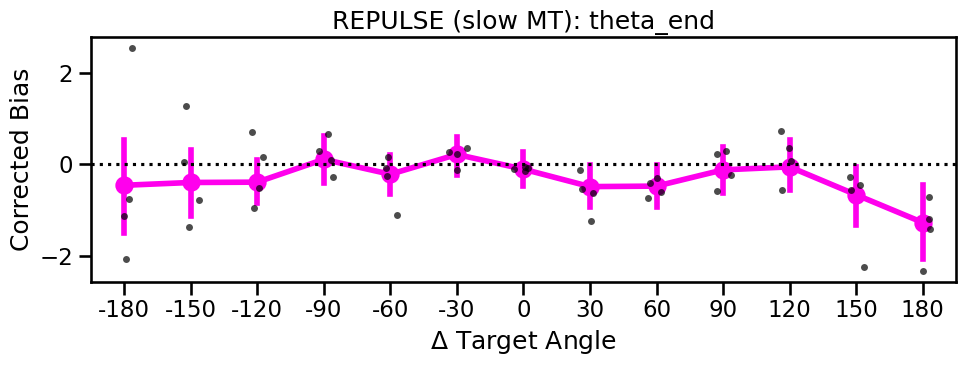

In [32]:
repulse_mask = (
    (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1]) & 
    (~df['mt'].isna()) &
    (df['mt'] > df['mt'].median()) & ## change this so that MT must be smaller than a certain  value. 
    (df['rt']  >0.5) &  
    (np.abs(df['theta_pv']) < 60)
)

df_repulse = df.loc[repulse_mask]

for angle in angle_cols:
    plot_bias(
        df_repulse,
        y_col=f"corrected_repulse_{angle}",
        title=f"REPULSE (slow MT): {angle}"
    )

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_3812/3434607866.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(N_finder, N_minus_targ=150)


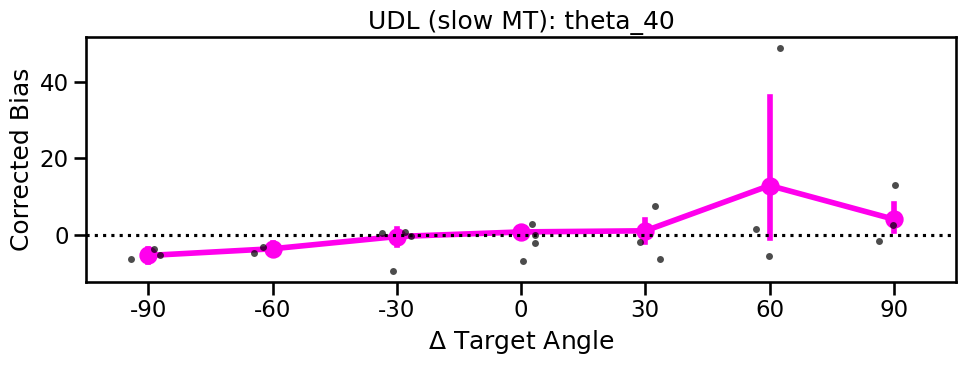

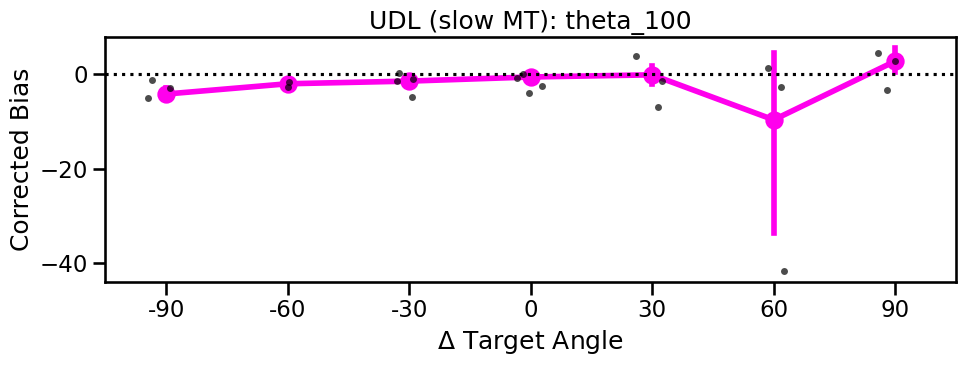

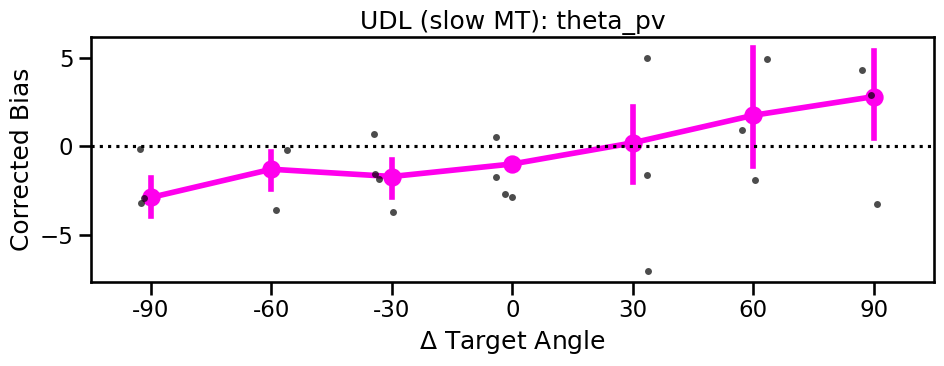

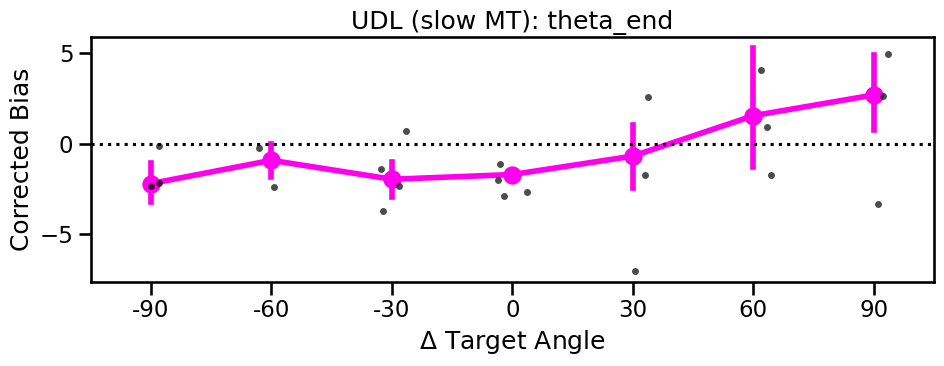

,SN,TN,peak_vel,theta_40,theta_100,theta_pv,rt,mt,theta_end,feedback,...,phase,bias_repulse_theta_40,corrected_repulse_theta_40,bias_repulse_theta_100,corrected_repulse_theta_100,bias_repulse_theta_pv,corrected_repulse_theta_pv,bias_repulse_theta_end,corrected_repulse_theta_end,target_angle_diff
0,1,0,51.883062,77.456559,102.787206,112.087521,2.693,NaN,125.245967,1,...,baseline,5.369309,72.087250,4.718530,98.068676,4.134394,107.953127,4.080911,121.165055,<NA>
1,1,1,108.103302,-3.628246,-2.074833,-1.348410,0.721,0.122,-1.348409,1,...,baseline,-0.198573,-3.429673,-0.824446,-1.250387,-0.989225,-0.359185,-0.989225,-0.359185,<NA>
2,1,2,89.804343,1.709924,-1.498633,-2.948737,0.750,0.134,-2.948738,1,...,baseline,-3.690345,5.400269,-2.887323,1.388691,-2.816851,-0.131885,-2.817233,-0.131505,<NA>
3,1,3,114.656146,4.250851,-0.600164,-0.971475,0.772,0.110,-0.971474,1,...,baseline,-0.957851,5.208702,0.744942,-1.345106,0.980879,-1.952354,0.985279,-1.956753,<NA>
4,1,4,93.171656,13.042442,3.996491,2.515876,0.720,0.137,2.515875,1,...,baseline,7.792518,5.249923,6.085384,-2.088893,5.782797,-3.266921,5.782796,-3.266921,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6315,4,1575,87.156352,-21.023986,-15.942538,-14.689628,0.644,0.133,-14.513767,0,...,udl,-2.419221,-18.604765,-0.519867,-15.422671,-0.233956,-14.455673,-0.122363,-14.391403,-30
6316,4,1576,93.557163,-11.432551,-7.230801,-6.500521,0.560,0.127,-6.500521,0,...,udl,-2.610842,-8.821710,-0.593585,-6.637216,-0.390966,-6.109555,-0.451134,-6.049388,30
6317,4,1577,92.028287,-10.330471,-6.370508,-6.332592,0.644,0.138,-6.332593,0,...,udl,-2.610842,-7.719629,-0.593585,-5.776923,-0.390966,-5.941626,-0.451134,-5.881459,0
6318,4,1578,106.384489,-8.907012,-7.036710,-7.186861,0.567,0.115,-7.186862,0,...,udl,-2.610842,-6.296171,-0.593585,-6.443125,-0.390966,-6.795895,-0.451134,-6.735728,0


In [33]:
mask_udl = (
    (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1]) & 
    (~df['mt'].isna()) & 
    (df['mt'] > df['mt'].median()) & ## constrain the MT 
    (df['rt'] > 0.500) & 
    (df['theta_pv'].abs() < 60)
)

df_udl = df.loc[mask_udl]

df_udl_constrained = (
    df_udl
    .groupby('SN', as_index=False)
    .apply(N_finder, N_minus_targ=150)
    .reset_index(drop=True)
)

df_udl_constrained = df_udl_constrained.loc[df_udl_constrained['feedback'] == 0]

for angle in angle_cols:
    plot_bias(
        df_udl_constrained,
        y_col=f"corrected_repulse_{angle}",
        title=f"UDL (slow MT): {angle}"
    )

df